*** 학습목표
- transformer기반의 모델 파인튜닝
- 허깅페이스 hub 활용 실습

In [1]:
import google.colab
print("Successfully imported google.colab!")

Successfully imported google.colab!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# To upload a file
from google.colab import files

# uploaded = files.upload()
# for fn in uploaded.keys():
#   print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

# To download a file (replace 'my_file.txt' with your file)
# with open('my_file.txt', 'w') as f:
#   f.write('Hello from Colab!')
# files.download('my_file.txt')

In [2]:
%cd /content/drive/MyDrive/AI/인사교_자연어처리

/content/drive/MyDrive/AI/인사교_자연어처리


1.데이터 로딩

In [5]:
!pip install --upgrade datasets

In [3]:
from datasets import load_dataset

In [4]:
dataset = load_dataset(
    "csv", # 읽을 데이터 포맷 설정
    data_files = {
        "train": "unsmile_train_v1.0.tsv",
        "test": "unsmile_valid_v1.0.tsv"
    },
    sep = '\t'
)

In [5]:
# 데이터 확인
dataset

DatasetDict({
    train: Dataset({
        features: ['문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설', 'clean', '개인지칭'],
        num_rows: 15005
    })
    test: Dataset({
        features: ['문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설', 'clean', '개인지칭'],
        num_rows: 3737
    })
})

In [6]:
# 컬럼 이름 추출하기
dataset["train"][0].keys()

dict_keys(['문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설', 'clean', '개인지칭'])

In [7]:
# 사용할 라벨이름 정리
unsmile_label = ['여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설', 'clean']

In [8]:
# 데이터 확인
dataset['test'][0]

{'문장': 'ㅇㄱㄹㅇ 진짜 죽어도 상관없다는 마인드로 싸웠더니 지금 서열 상타취노 식칼들고 니가 나 안찌르면 내가 너 찌른다 했더니 애비충 냄동충 알아서기노 ^됫^ 한번 서열 잡고 그 담에 개길때마다 더 세게나가면 확실하게 짓누를수있다익이',
 '여성/가족': 0,
 '남성': 1,
 '성소수자': 0,
 '인종/국적': 0,
 '연령': 0,
 '지역': 0,
 '종교': 0,
 '기타 혐오': 0,
 '악플/욕설': 0,
 'clean': 0,
 '개인지칭': 0}

###2. 학습을 위한 클래스 준비

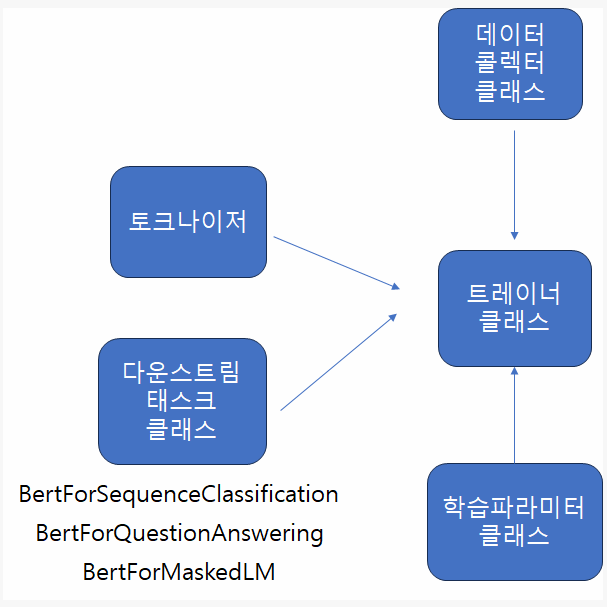

###토크나이저 로딩

In [3]:
from transformers import AutoTokenizer # 토크나이저를 다운받는 클래스

In [6]:
# 사용할 사전학습 모델
model_name = "beomi/kcbert-base"

In [11]:
# 사전학습모델에 맞는 토크나이저 다운로드
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [12]:


# Assuming model_name is already defined from a previous cell
# If not, ensure model_name = "beomi/kcbert-base" is also present or executed.
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 샘플문장 변경
tokenizer(dataset['train'][0]['문장'])

{'input_ids': [2, 2458, 15751, 24930, 24351, 29278, 17038, 11631, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [13]:
#학습을 위한 전처리 함수 만들기
import torch

In [21]:
def preprocessing(document) : # 매개변수로 문서 1개가 들어오도록 함
    # 1. 문장 토큰화, 수치화
    if document['문장'] == None :
      txt = ''
    else :
      txt = document['문장']
    token_str = tokenizer(txt)
    # 2. 정답 데이터 추가 (확률정보로 변경)
    label_list = [ float(document[class_name]) for class_name in unsmile_label ]
    token_str['labels'] = torch.tensor(label_list) # 파이토치 데이터타입으로 변경해서 추가

    return token_str

In [19]:
dataset['train'][0]

{'문장': '일안하는 시간은 쉬고싶어서 그런게 아닐까',
 '여성/가족': 0,
 '남성': 0,
 '성소수자': 0,
 '인종/국적': 0,
 '연령': 0,
 '지역': 0,
 '종교': 0,
 '기타 혐오': 0,
 '악플/욕설': 0,
 'clean': 1,
 '개인지칭': 0}

In [22]:
# 모든 데이터에 전처리 함수 적용
tokenized_dataset = dataset.map(preprocessing)

Map:   0%|          | 0/15005 [00:00<?, ? examples/s]

Map:   0%|          | 0/3737 [00:00<?, ? examples/s]

In [23]:
tokenized_dataset['train'][0]

{'문장': '일안하는 시간은 쉬고싶어서 그런게 아닐까',
 '여성/가족': 0,
 '남성': 0,
 '성소수자': 0,
 '인종/국적': 0,
 '연령': 0,
 '지역': 0,
 '종교': 0,
 '기타 혐오': 0,
 '악플/욕설': 0,
 'clean': 1,
 '개인지칭': 0,
 'input_ids': [2, 2458, 15751, 24930, 24351, 29278, 17038, 11631, 3],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1],
 'labels': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]}

In [24]:
# 불필요한 컬럼제거
tokenized_dataset.set_format(type='torch', columns=["input_ids",'token_type_ids',
                                                    'attention_mask','labels'])

In [25]:
tokenized_dataset['train'][0]

{'input_ids': tensor([    2,  2458, 15751, 24930, 24351, 29278, 17038, 11631,     3]),
 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'labels': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])}

#### 파인튜닝할 모델 로딩(다운스트림 태크스)

In [4]:
from transformers import AutoModelForSequenceClassification

In [7]:
# kcbert기반 분류모델 다운로드
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, # 활용할 모델 저장소 이름
    num_labels = 10, # 분류할 클래스 수
    problem_type = "multi_label_classification" # 멀티레이블 다중분류
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


#### 데이터콜레터 준비

In [28]:
# 데이터를 묶어서 트레이너에 넘겨주는 역할
from transformers import DataCollatorWithPadding # 패딩작업 후 배치사이즈 만큼 묶어서 넘겨주는 역할


In [29]:
#다이나믹패딩을 기본적으로 지원
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#### 학습파라미터 관리하는 도구

In [30]:
from transformers import TrainingArguments

In [31]:
args = TrainingArguments(
    learning_rate = 2e-5, # 학습률
    per_device_train_batch_size = 256, #훈련용 배치사이즈
    per_device_eval_batch_size = 256, #검증용 배치사이즈
    num_train_epochs = 2, # 학습 횟수 설정
    output_dir = "./model_output", # 학습결과가 저장될 경로(모델체크포인트 역할)
    save_strategy = "epoch", # 매 에포크 마다 파일 저장
    greater_is_better = True, # 베스트 모델 저장
    load_best_model_at_end=True, # 학습종료시 베스트모델 로딩
    eval_strategy = "epoch" # 검증시점 설정
)

#### 멀티레이블 문제용 평가함수

In [32]:
# 멀티라벨 문제 평가함수 설정
from sklearn.metrics import label_ranking_average_precision_score

# torch와 호환을 위해 사용자정의 함수로 감싸준다
def my_metrics(x) :
  return {
      'lrap' : label_ranking_average_precision_score(x.label_ids, x.predictions)
  }

In [33]:
import sys

# torchvision이 이미 import되어 있으면 dataset가 VideoReader를 건드림(버전이 올라가면서 충돌)
if "torchvision" in sys.modules:
    del sys.modules["torchvision"]

### 학습을 위한 트레이너 생성

In [35]:
from transformers import Trainer

In [36]:
trainer = Trainer(
    model = model, # 학습할 모델 연결
    args = args, # 학습 파라미터 연결
    processing_class = tokenizer, # 전처리 도구 연결
    data_collator = data_collator, # 데이터 관리 도구 연결
    train_dataset = tokenized_dataset['train'], # 훈련용 데이터 연결
    eval_dataset = tokenized_dataset['test'], # 검증용 데이터 연결
    compute_metrics = my_metrics # 평가함수 연결
)

In [37]:
trainer.train()

Epoch,Training Loss,Validation Loss,Lrap
1,No log,0.251141,0.745957
2,No log,0.209717,0.819405


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=118, training_loss=0.2850564213122352, metrics={'train_runtime': 94.5585, 'train_samples_per_second': 317.37, 'train_steps_per_second': 1.248, 'total_flos': 1116585793980720.0, 'train_loss': 0.2850564213122352, 'epoch': 2.0})

In [41]:
# 학습을 위한 전처리 함수 만들기
import torch

In [42]:
def preprocessing(document) : # 매개변수로 문서 1개가 들어오도록 함
    # 1. 문장 토큰화, 수치화
    if document['문장'] == None :
      txt = ''
    else :
      txt = document['문장']
    token_str = tokenizer(txt)
    # 2. 정답 데이터 추가 (확률정보로 변경)
    label_list = [ float(document[class_name]) for class_name in unsmile_label]
    token_str['labels'] = torch.tensor(label_list) # 파이토치 데이터타입으로 변경해서 추가

    return token_str

In [43]:
# 모든 데이터에 전처리 함수 적용
tokenized_dataset = dataset.map(preprocessing)

Map:   0%|          | 0/15005 [00:00<?, ? examples/s]

Map:   0%|          | 0/3737 [00:00<?, ? examples/s]

In [44]:
best_model = model.from_pretrained("/content/drive/MyDrive/AI/인사교_자연어처리/model_output/checkpoint-118")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [46]:
#토크나이저로딩
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/AI/인사교_자연어처리/model_output/checkpoint-118")

In [8]:
#허깅페이스 로그인하기
import huggingface_hub
huggingface_hub.login()

In [48]:
trainer.push_to_hub("my_unsmile")

HfHubHTTPError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a38a288-6d03ddec132946fe14164d1b;52368ddb-9509-480c-9061-f96d5550a71c)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

Invalid username or password.

In [9]:
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/AI/인사교_자연어처리/model_output/checkpoint-118")

In [51]:
# 저장소에 업로드시 함께 기입할 정보 작성
kwargs = {
    'fientuned_from': model.config.name_or_path, # 파인튜닝한 사전모델 정보
    'task': 'text_classification', # task 종류 표기
    'dataset': 'naver_movie', # 활용한 데이터셋 표기
    'tags' : ['HHD', 'binary_class'] # 기타 정보
}

In [11]:
best_model = model.from_pretrained("/content/drive/MyDrive/AI/인사교_자연어처리/model_output/checkpoint-118")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [12]:
# 모델 및 토크나이저 업로드
best_model.push_to_hub("unsmile")

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...u_l9d81/model.safetensors:   0%|          |  551kB /  436MB            

CommitInfo(commit_url='https://huggingface.co/johnsinana/unsmile/commit/cd109bbebe0e2985b5e635e30ef96f9de787548b', commit_message='Upload BertForSequenceClassification', commit_description='', oid='cd109bbebe0e2985b5e635e30ef96f9de787548b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/johnsinana/unsmile', endpoint='https://huggingface.co', repo_type='model', repo_id='johnsinana/unsmile'), pr_revision=None, pr_num=None)

In [10]:
tokenizer.push_to_hub("unsmile")

CommitInfo(commit_url='https://huggingface.co/johnsinana/unsmile/commit/710d670898556ed5011d3ec22df4ea508ec06128', commit_message='Upload tokenizer', commit_description='', oid='710d670898556ed5011d3ec22df4ea508ec06128', pr_url=None, repo_url=RepoUrl('https://huggingface.co/johnsinana/unsmile', endpoint='https://huggingface.co', repo_type='model', repo_id='johnsinana/unsmile'), pr_revision=None, pr_num=None)

In [13]:
# 내 모델 불러오기
from transformers import pipeline

In [14]:
classifier = pipeline(
    task = "text-classification", # task 이름
    model = "johnsinana/unsmile", # 모델이름
    device = 0 # 0 -> GPU 0번째로 추론하겠다는 뜻
)

config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/721k [00:00<?, ?B/s]

In [15]:
classifier("이 영화 재밌네요")

[{'label': 'LABEL_9', 'score': 0.8155299425125122}]

In [ ]:
classifier("존잼")

[{'label': 'LABEL_1', 'score': 0.9714993238449097}]